# Project 2 — Exploratory Data Analysis (EDA)
**E-commerce orders · 1,200 orders × 14 columns · Jan 2023 – Jun 2025**
*DecodeLabs Data Analytics Internship — Batch 2026*

**Core question:** What do the order data tell us about *where revenue comes from*, *how much of it is real*, and *what deserves a closer look* before any dashboard or model is built?

**Method (IPO):** Input = Project 1 dataset → Process = descriptive stats, distributions, outliers (IQR), correlation, group comparisons → Output = business insights ("So what?").

**Headline findings**
1. **41% of order revenue is Cancelled or Returned** — gross revenue of ₹1.26M overstates what the business can keep.
2. **Revenue is right-skewed** (mean ₹1,054 vs median ₹824) — typical order is smaller than the "average".
3. **Products, payment methods, coupons and referral sources look interchangeable** — differences are small and not statistically significant.
4. **Orders peak in June and fall in H2**, and H1 revenue has declined each year (2023 → 2025).
5. **The 0.717 UnitPrice↔TotalPrice correlation is arithmetic, not a discovery** (TotalPrice = Quantity × UnitPrice exactly).

## 1. Understand the dataset

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, matplotlib.ticker as mtick, seaborn as sns
from scipy import stats
pd.set_option('display.float_format','{:,.2f}'.format); pd.set_option('display.width',140)

ACC, GREY, DARK, RED = '#2a6f97', '#b9c0c7', '#33393f', '#c0392b'
plt.rcParams.update({'figure.dpi':110,'axes.spines.top':False,'axes.spines.right':False,'axes.edgecolor':'#888',
  'axes.titleweight':'bold','axes.titlesize':12,'axes.titlelocation':'left','axes.grid':True,'grid.color':'#e6e9ec',
  'grid.linewidth':.7,'axes.axisbelow':True,'font.size':10})
inr = mtick.FuncFormatter(lambda x,_: f'₹{x:,.0f}')
def save(name): plt.tight_layout(); plt.savefig(f'figures/{name}.png',dpi=150,bbox_inches='tight'); plt.show()

PATH = 'Dataset_for_Data_Analytics.xlsx'
df = pd.read_excel(PATH)
print('Shape:', df.shape)
df.head()

Shape: (1200, 14)


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,"2,853.10"
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,"2,753.40"
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,"2,504.04"


In [2]:
print(df.dtypes.to_string())
print('\nMissing values per column:'); print(df.isna().sum()[df.isna().sum()>0].to_string())
print('\nDuplicate rows:', df.duplicated().sum(), '| duplicate OrderIDs:', df.OrderID.duplicated().sum())

OrderID                       str
Date               datetime64[us]
CustomerID                    str
Product                       str
Quantity                    int64
UnitPrice                 float64
ShippingAddress               str
PaymentMethod                 str
OrderStatus                   str
TrackingNumber                str
ItemsInCart                 int64
CouponCode                    str
ReferralSource                str
TotalPrice                float64

Missing values per column:
CouponCode    309

Duplicate rows: 0 | duplicate OrderIDs: 0


**Data-quality note.** The only gaps are **309 blank `CouponCode` values (25.8%)**. A blank coupon means *no coupon was used*, not lost information, so I label them `No Coupon` rather than dropping or imputing. After that the dataset has no missing values, no duplicate rows and no duplicate OrderIDs.

In [3]:
df['CouponCode'] = df['CouponCode'].fillna('No Coupon')
df['Month'] = df.Date.dt.to_period('M').dt.to_timestamp()
print('Missing values after labelling:', df.isna().sum().sum())
print('Date range:', df.Date.min().date(), '→', df.Date.max().date())

# Integrity checks that matter for interpretation
print('\nTotalPrice == Quantity × UnitPrice for every row:', np.allclose(df.TotalPrice, df.Quantity*df.UnitPrice))
print('ItemsInCart >= Quantity for every row:', (df.ItemsInCart>=df.Quantity).all())
print('Repeat CustomerIDs:', df.CustomerID.duplicated().sum(), 'of', len(df))

Missing values after labelling: 0
Date range: 2023-01-01 → 2025-06-30

TotalPrice == Quantity × UnitPrice for every row: True
ItemsInCart >= Quantity for every row: True
Repeat CustomerIDs: 11 of 1200


Two structural facts shape everything below:
- **`TotalPrice = Quantity × UnitPrice` exactly.** So TotalPrice is a derived column, and its correlations with those two inputs are mechanical.
- **`ItemsInCart ≥ Quantity` in every row** (you can't buy more of an item than is in the cart), which mechanically links those two as well.

## 2. Descriptive statistics

In [4]:
num = ['Quantity','UnitPrice','ItemsInCart','TotalPrice']
desc = df[num].agg(['count','mean','median','min','max']).T
desc['Q1']=df[num].quantile(.25); desc['Q3']=df[num].quantile(.75); desc['Std']=df[num].std()
desc['Skew']=df[num].skew()
desc[['count','mean','median','min','Q1','Q3','max','Std','Skew']]

,count,mean,median,min,Q1,Q3,max,Std,Skew
Quantity,"1,200.00",2.95,3.00,1.00,2.00,4.00,5.00,1.41,0.03
UnitPrice,"1,200.00",356.41,364.21,11.39,186.06,521.57,699.93,197.18,-0.03
ItemsInCart,"1,200.00",5.49,5.00,1.00,4.00,7.00,10.00,2.28,0.00
TotalPrice,"1,200.00","1,053.97",823.62,11.39,410.52,"1,578.47","3,456.40",819.86,0.89


`TotalPrice` is the only clearly skewed variable (skew ≈ 0.89; mean ₹1,054 > median ₹824, a gap of ₹230). `Quantity`, `UnitPrice` and `ItemsInCart` are almost perfectly symmetric (skew ≈ 0) — they look **uniformly distributed**, which is unusual for real retail data. The right skew in revenue arises purely from multiplying two flat distributions.

## 3. Univariate analysis

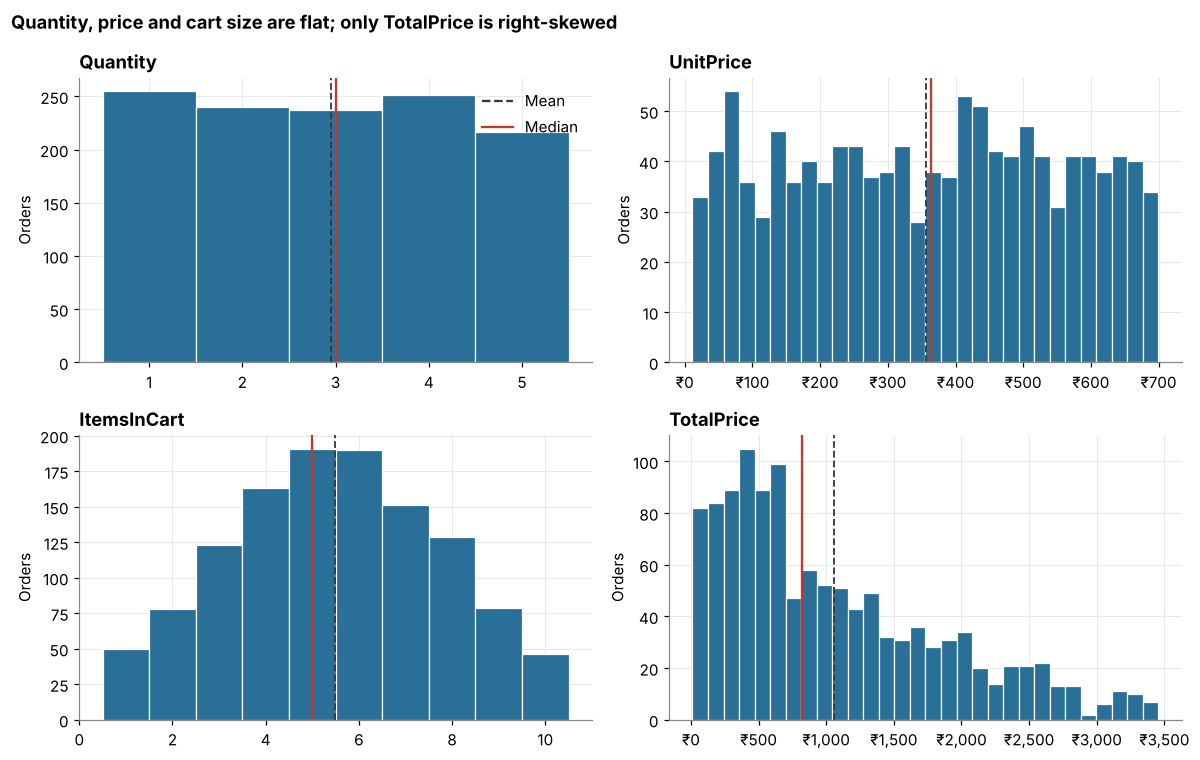

In [5]:
fig, ax = plt.subplots(2,2, figsize=(11,7))
for a,(c,b) in zip(ax.ravel(), [('Quantity',np.arange(.5,6.5,1)),('UnitPrice',30),('ItemsInCart',np.arange(.5,11.5,1)),('TotalPrice',30)]):
    a.hist(df[c], bins=b, color=ACC, edgecolor='white', linewidth=.8)
    a.axvline(df[c].mean(), color=DARK, ls='--', lw=1.2); a.axvline(df[c].median(), color=RED, lw=1.5)
    a.set_title(c); a.set_ylabel('Orders')
    if c in ('UnitPrice','TotalPrice'): a.xaxis.set_major_formatter(inr)
ax[0,0].plot([],[],color=DARK,ls='--',label='Mean'); ax[0,0].plot([],[],color=RED,label='Median'); ax[0,0].legend(frameon=False)
fig.suptitle('Quantity, price and cart size are flat; only TotalPrice is right-skewed', x=.01, ha='left', fontweight='bold')
save('01_univariate')

**What it shows:** the first three histograms are flat — every quantity (1–5) and cart size (1–10) is about equally common, and unit prices are spread evenly from ₹11 to ₹700. `TotalPrice` has a long right tail, so the **median (₹824) is the better description of a "typical" order** than the mean (₹1,054).

## 4. Categorical analysis

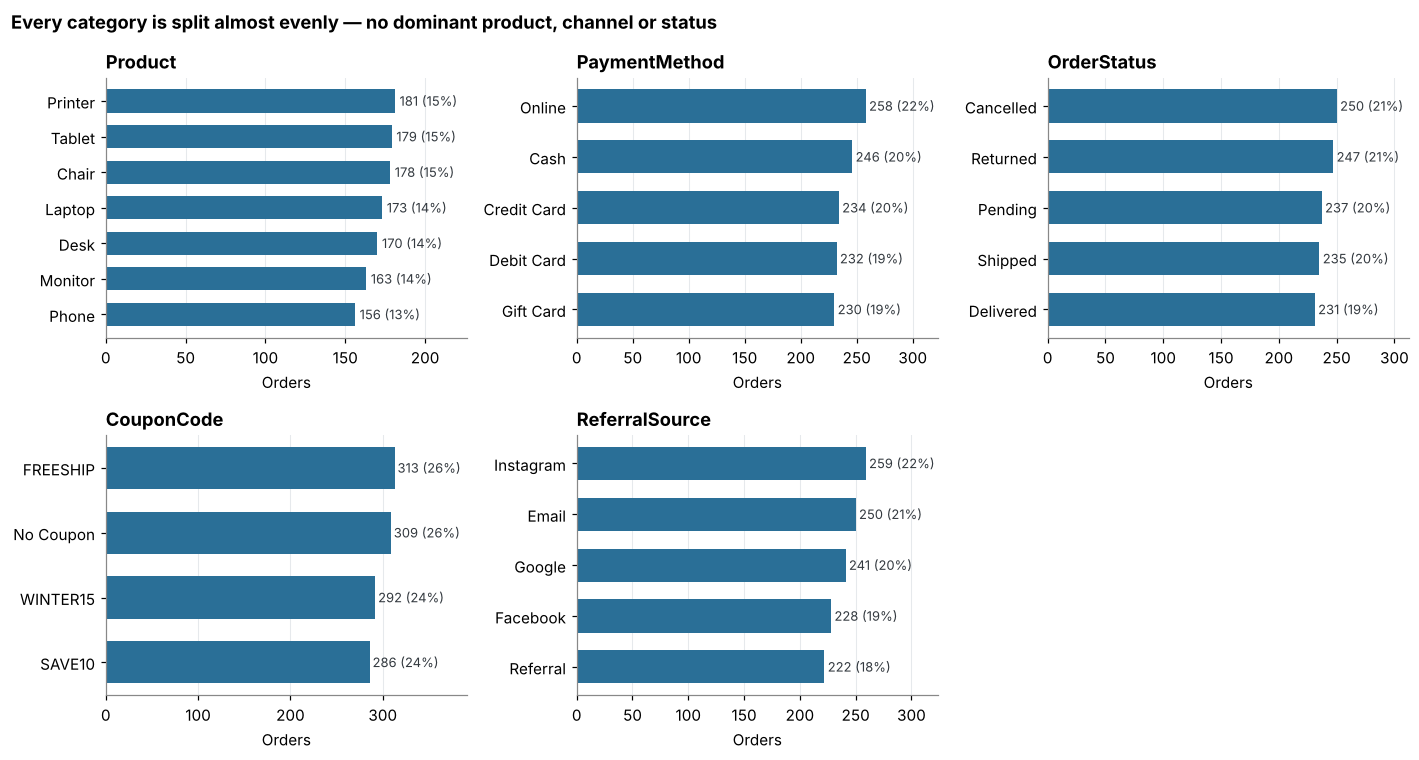

,Largest share,Smallest share
Product,15.1%,13.0%
PaymentMethod,21.5%,19.2%
OrderStatus,20.8%,19.2%
CouponCode,26.1%,23.8%
ReferralSource,21.6%,18.5%


In [6]:
cats = ['Product','PaymentMethod','OrderStatus','CouponCode','ReferralSource']
fig, ax = plt.subplots(2,3, figsize=(13,7)); ax=ax.ravel()
for a,c in zip(ax,cats):
    vc = df[c].value_counts().sort_values()
    a.barh(vc.index, vc.values, color=ACC, height=.65)
    a.set_title(c); a.set_xlabel('Orders'); a.grid(axis='y', visible=False)
    for y,v in enumerate(vc.values): a.text(v+3, y, f'{v} ({v/len(df):.0%})', va='center', fontsize=8.5, color=DARK)
    a.set_xlim(0, vc.max()*1.25)
ax[-1].axis('off')
fig.suptitle('Every category is split almost evenly — no dominant product, channel or status', x=.01, ha='left', fontweight='bold')
save('02_categorical')
pd.DataFrame({c: df[c].value_counts(normalize=True).agg(['max','min']) for c in cats}).T.rename(columns={'max':'Largest share','min':'Smallest share'}).style.format('{:.1%}')

**What it shows:** no category is dominant. Largest-vs-smallest shares are within a few percentage points everywhere (e.g. Product 13.0%–15.1%, OrderStatus 19.3%–20.8%). The one notable level is **`OrderStatus`: Cancelled (20.8%) + Returned (20.6%) = 41.4% of all orders**, which is explored in §8.

## 5. Time analysis

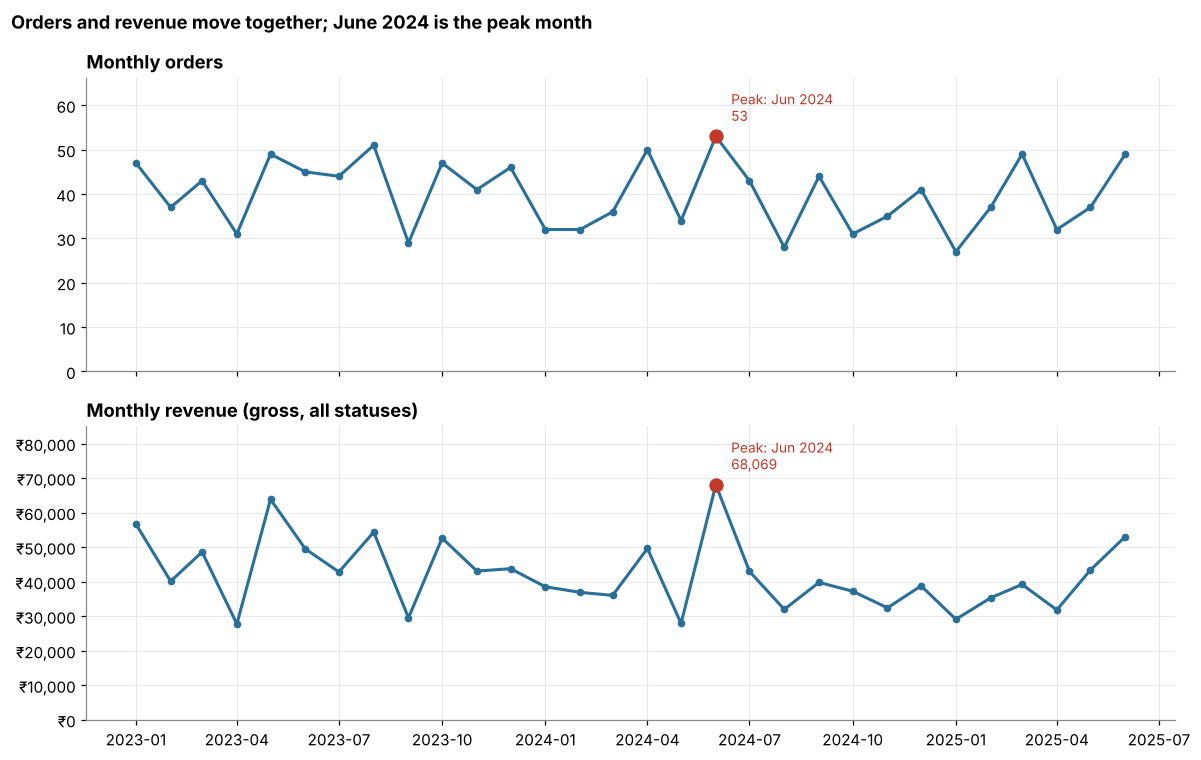

,Orders,Revenue,AvgOrderValue
mean,40.00,"42,158.73","1,051.80"
min,27.00,"27,751.71",800.01
max,53.00,"68,068.54","1,302.79"


In [7]:
m = df.groupby('Month').agg(Orders=('OrderID','size'), Revenue=('TotalPrice','sum'))
fig, ax = plt.subplots(2,1, figsize=(11,7), sharex=True)
for a,c,t in zip(ax,['Orders','Revenue'],['Monthly orders','Monthly revenue (gross, all statuses)']):
    a.plot(m.index, m[c], color=ACC, lw=2, marker='o', ms=4)
    top = m[c].idxmax(); a.scatter([top],[m[c].max()], s=70, color=RED, zorder=5)
    a.annotate(f'Peak: {top:%b %Y}\n{m[c].max():,.0f}', (top,m[c].max()), xytext=(10,8), textcoords='offset points', color=RED, fontsize=9, va='bottom')
    a.set_title(t); a.set_ylim(0, m[c].max()*1.25)
ax[1].yaxis.set_major_formatter(inr)
fig.suptitle('Orders and revenue move together; June 2024 is the peak month', x=.01, ha='left', fontweight='bold')
save('03_monthly')
m.assign(AvgOrderValue=m.Revenue/m.Orders).describe().loc[['mean','min','max']]

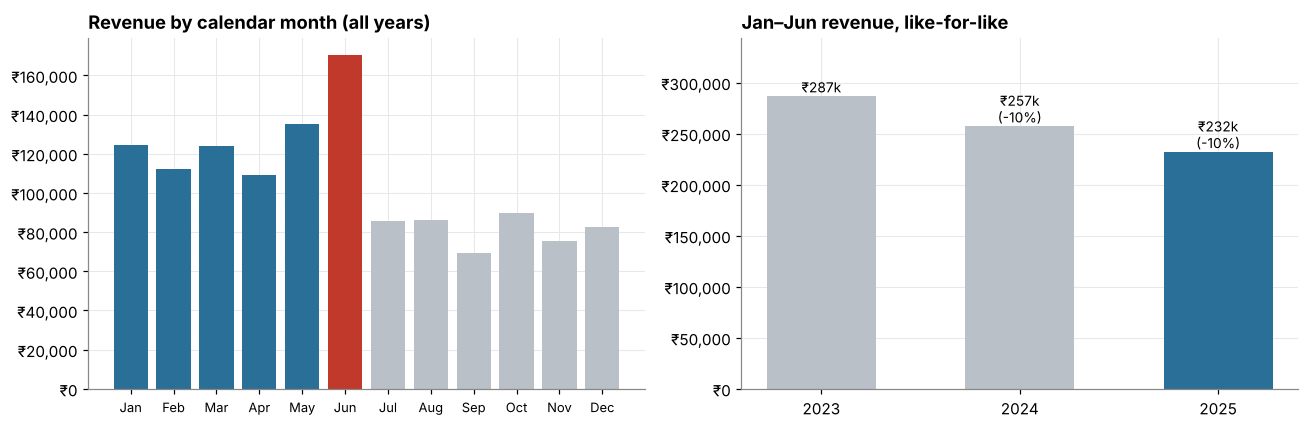

H1 (Jan–Jun) share of revenue: 61.3%


,Orders,Revenue,Revenue YoY,Orders YoY
Date,,,,
2023,252,"286,501.52",NaN,NaN
2024,237,"257,059.34",-0.10,-0.06
2025,231,"231,882.85",-0.10,-0.03


In [8]:
# Seasonality: average by calendar month, and like-for-like H1 comparison (2025 only has Jan–Jun)
cm = df.groupby(df.Date.dt.month).agg(Orders=('OrderID','size'), Revenue=('TotalPrice','sum'))
h1 = df[df.Date.dt.month<=6].groupby(df.Date.dt.year).agg(Orders=('OrderID','size'), Revenue=('TotalPrice','sum'))
h1['Revenue YoY'] = h1.Revenue.pct_change(); h1['Orders YoY']=h1.Orders.pct_change()

fig, ax = plt.subplots(1,2, figsize=(12,4))
cols=[RED if mth==6 else (ACC if mth<=6 else GREY) for mth in cm.index]
ax[0].bar(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], cm.Revenue, color=cols)
ax[0].set_title('Revenue by calendar month (all years)'); ax[0].tick_params(axis='x', labelsize=8.5); ax[0].yaxis.set_major_formatter(inr)
ax[1].bar(h1.index.astype(str), h1.Revenue, color=[GREY,GREY,ACC], width=.55)
for x,(v,y) in enumerate(zip(h1.Revenue,h1['Revenue YoY'])): ax[1].text(x, v+4000, f'₹{v/1000:,.0f}k'+('' if np.isnan(y) else f'\n({y:+.0%})'), ha='center', fontsize=9)
ax[1].set_title('Jan–Jun revenue, like-for-like'); ax[1].yaxis.set_major_formatter(inr); ax[1].set_ylim(0,h1.Revenue.max()*1.2)
save('04_seasonality')
print('H1 (Jan–Jun) share of revenue:', f"{cm.Revenue[:6].sum()/cm.Revenue.sum():.1%}"); h1

**What it shows:**
- **Strong H1/H2 split:** January–June brings in ~61% of revenue; **June alone is the biggest month** (147 orders, ₹170.6k). July–December is consistently weaker.
- **Like-for-like (Jan–Jun) revenue is shrinking:** ₹286k (2023) → ₹257k (2024, −10%) → ₹232k (2025, −10%). I compare H1 to H1 because 2025 data stops at June; comparing full-year totals would wrongly show a 50% collapse.
- With only 2.5 years of data, "seasonality" is a pattern worth testing, not a proven cycle.

## 6. Outlier analysis (IQR)

In [9]:
t = df.TotalPrice; Q1,Q3 = t.quantile(.25), t.quantile(.75); IQR = Q3-Q1
lo, hi = Q1-1.5*IQR, Q3+1.5*IQR
out = df[(t<lo)|(t>hi)]
print(f'Q1={Q1:,.2f}  Q3={Q3:,.2f}  IQR={IQR:,.2f}  lower={lo:,.2f}  upper={hi:,.2f}')
print('Outliers:', len(out), f'({len(out)/len(df):.2%} of orders, ₹{out.TotalPrice.sum():,.0f} revenue = {out.TotalPrice.sum()/t.sum():.1%})')
out[['OrderID','Date','Product','Quantity','UnitPrice','ItemsInCart','PaymentMethod','OrderStatus','TotalPrice']].sort_values('TotalPrice',ascending=False)

Q1=410.52  Q3=1,578.47  IQR=1,167.95  lower=-1,341.41  upper=3,330.41
Outliers: 8 (0.67% of orders, ₹27,033 revenue = 2.1%)


,OrderID,Date,Product,Quantity,UnitPrice,ItemsInCart,PaymentMethod,OrderStatus,TotalPrice
789,ORD200789,2023-08-17,Tablet,5,691.28,10,Online,Delivered,"3,456.40"
1122,ORD201122,2023-06-07,Monitor,5,678.19,8,Online,Returned,"3,390.95"
632,ORD200632,2023-05-02,Laptop,5,678.16,7,Gift Card,Delivered,"3,390.80"
469,ORD200469,2023-11-26,Chair,5,676.98,5,Cash,Cancelled,"3,384.90"
328,ORD200328,2023-02-28,Tablet,5,674.04,7,Online,Cancelled,"3,370.20"
107,ORD200107,2023-03-27,Printer,5,670.75,8,Gift Card,Shipped,"3,353.75"
326,ORD200326,2024-07-01,Laptop,5,670.48,5,Gift Card,Returned,"3,352.40"
1065,ORD201065,2023-10-30,Printer,5,666.80,7,Debit Card,Delivered,"3,334.00"


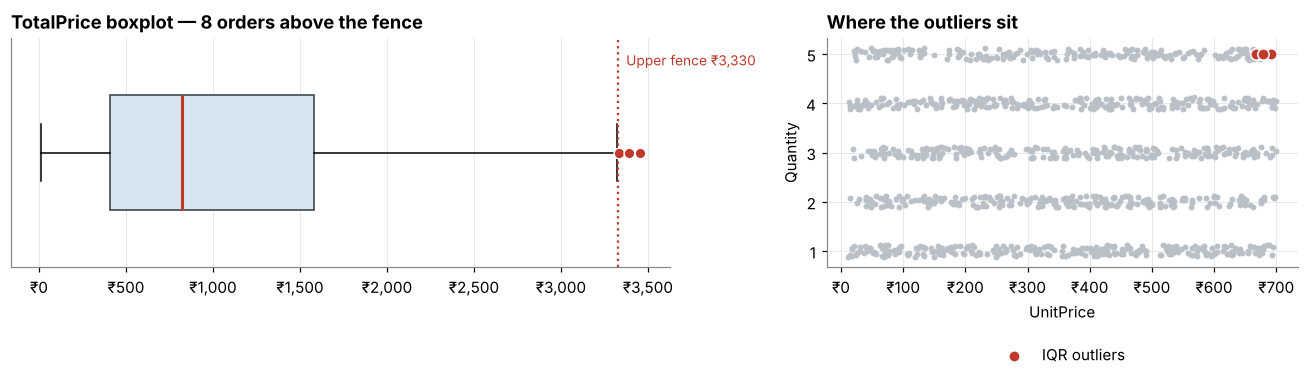

Outlier statuses: {'Delivered': 3, 'Returned': 2, 'Cancelled': 2, 'Shipped': 1}
Outlier quantities: {5: 8} | min unit price: 666.8


In [10]:
fig, ax = plt.subplots(1,2, figsize=(12,3.8), gridspec_kw={'width_ratios':[1.4,1]})
ax[0].boxplot(t, orientation='horizontal', widths=.5, patch_artist=True, boxprops=dict(facecolor='#d6e6f0', edgecolor=DARK),
              medianprops=dict(color=RED, lw=2), flierprops=dict(marker='o', mfc=RED, mec='white', ms=7))
ax[0].axvline(hi, color=RED, ls=':'); ax[0].text(hi, 1.38, f'  Upper fence ₹{hi:,.0f}', color=RED, fontsize=9)
ax[0].set_yticks([]); ax[0].xaxis.set_major_formatter(inr); ax[0].set_title('TotalPrice boxplot — 8 orders above the fence'); ax[0].grid(axis='y', visible=False)
ax[1].scatter(df.UnitPrice, df.Quantity+np.random.default_rng(1).uniform(-.12,.12,len(df)), s=8, color=GREY)
ax[1].scatter(out.UnitPrice, out.Quantity, s=55, color=RED, edgecolor='white', label='IQR outliers')
ax[1].xaxis.set_major_formatter(inr); ax[1].set_xlabel('UnitPrice'); ax[1].set_ylabel('Quantity'); ax[1].legend(frameon=False, loc='upper center', bbox_to_anchor=(.5,-.28), ncol=1)
ax[1].set_title('Where the outliers sit')
save('05_outliers')
print('Outlier statuses:', out.OrderStatus.value_counts().to_dict())
print('Outlier quantities:', out.Quantity.value_counts().to_dict(), '| min unit price:', out.UnitPrice.min())

**Verdict: signal, not noise.** The 8 high-value orders are all **Quantity 5 at unit prices of ₹667–₹691** — the top corner of two valid ranges multiplied together, not typos or impossible values. Each is internally consistent (TotalPrice = Quantity × UnitPrice), so **they are retained**. But they deserve follow-up: **4 of the 8 were Cancelled or Returned**, so half of the biggest orders produced no kept revenue.

## 7. Correlation analysis

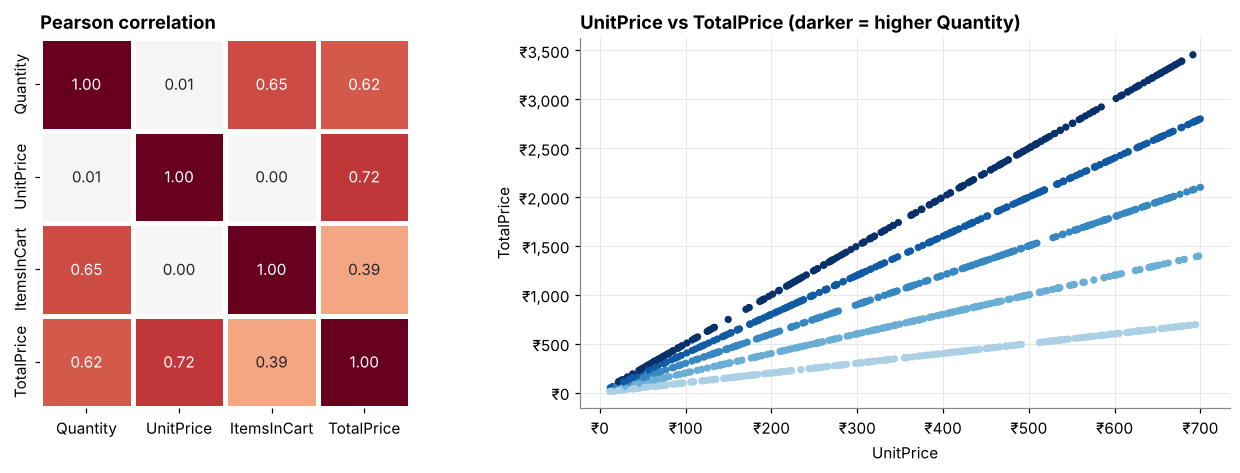

UnitPrice    TotalPrice    0.72
Quantity     ItemsInCart   0.65
             TotalPrice    0.62
ItemsInCart  TotalPrice    0.39
Quantity     UnitPrice     0.01
UnitPrice    ItemsInCart   0.00
Name: r, dtype: float64

In [11]:
corr = df[num].corr()
fig, ax = plt.subplots(1,2, figsize=(12,4.4), gridspec_kw={'width_ratios':[1,1.15]})
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1, center=0, square=True, cbar=False, linewidths=2, linecolor='white', ax=ax[0])
ax[0].set_title('Pearson correlation')
ax[1].scatter(df.UnitPrice, df.TotalPrice, c=df.Quantity, cmap='Blues', s=14, vmin=-1)
ax[1].xaxis.set_major_formatter(inr); ax[1].yaxis.set_major_formatter(inr)
ax[1].set_xlabel('UnitPrice'); ax[1].set_ylabel('TotalPrice'); ax[1].set_title('UnitPrice vs TotalPrice (darker = higher Quantity)')
save('06_correlation')
pairs = corr.where(np.triu(np.ones(corr.shape),1).astype(bool)).stack().dropna().rename('r').sort_values(ascending=False); pairs

**What it shows:** UnitPrice↔TotalPrice r = 0.717, Quantity↔TotalPrice r = 0.615, ItemsInCart↔TotalPrice r = 0.393, Quantity↔ItemsInCart r = 0.650.

**Correlation ≠ causation — and here it isn't even a finding.** The fan shape in the scatter is the signature of a *product*: TotalPrice = Quantity × UnitPrice. Of course price and quantity correlate with their own product. The same goes for Quantity↔ItemsInCart (the cart can't hold fewer items than you buy).

The informative result is the opposite one: **UnitPrice and Quantity are uncorrelated (r = 0.015)** — customers do not buy fewer units of pricier items, as demand intuition would suggest. Ordering more units doesn't depend on price here, so *both* levers independently grow order value. ItemsInCart ↔ TotalPrice (0.39) is only an indirect effect through Quantity.

## 8. Relationship analysis

### 8a. Product vs revenue

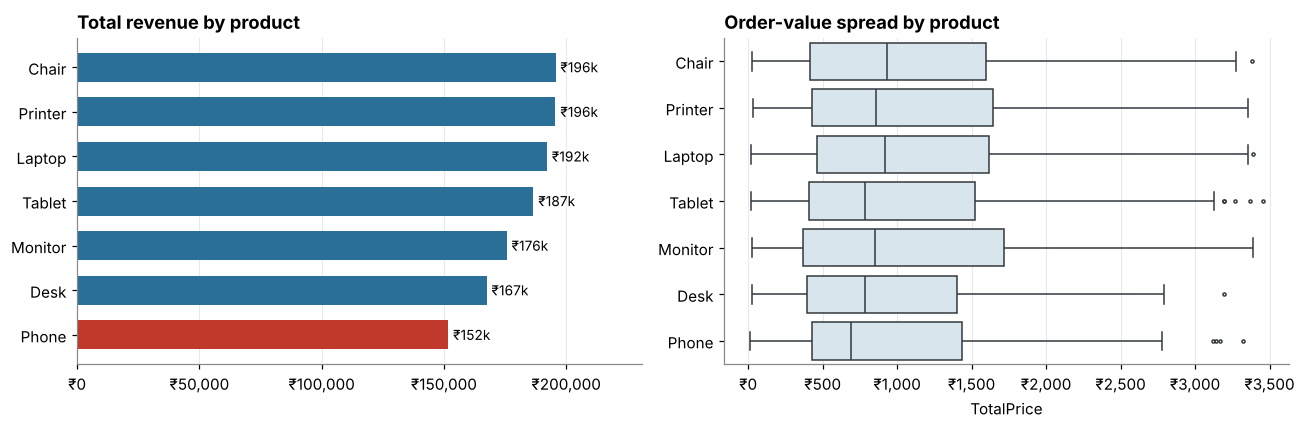

ANOVA: does mean order value differ by Product?  F=0.74, p=0.62


,Orders,Revenue,Avg_Order,Median_Order,Revenue_Share
Product,,,,,
Chair,178,"195,620.11","1,098.99",928.58,0.15
Printer,181,"195,612.61","1,080.73",857.40,0.15
Laptop,173,"192,126.56","1,110.56",915.64,0.15
Tablet,179,"186,568.95","1,042.28",786.66,0.15
Monitor,163,"175,651.41","1,077.62",853.40,0.14
Desk,170,"167,459.93",985.06,784.39,0.13
Phone,156,"151,722.39",972.58,691.71,0.12


In [12]:
def summ(c):
    g = df.groupby(c).TotalPrice.agg(Orders='count', Revenue='sum', Avg_Order='mean', Median_Order='median')
    g['Revenue_Share'] = g.Revenue/g.Revenue.sum(); return g.sort_values('Revenue', ascending=False)
prod = summ('Product')
fig, ax = plt.subplots(1,2, figsize=(12,4))
p = prod.sort_values('Revenue')
ax[0].barh(p.index, p.Revenue, color=[RED if i=='Phone' else ACC for i in p.index], height=.65)
for y,v in enumerate(p.Revenue): ax[0].text(v+2000, y, f'₹{v/1000:,.0f}k', va='center', fontsize=9)
ax[0].set_title('Total revenue by product'); ax[0].xaxis.set_major_formatter(inr); ax[0].set_xlim(0,p.Revenue.max()*1.18); ax[0].grid(axis='y',visible=False)
order = prod.index
sns.boxplot(data=df, y='Product', x='TotalPrice', order=order, color='#d6e6f0', linecolor=DARK, fliersize=2, ax=ax[1])
ax[1].xaxis.set_major_formatter(inr); ax[1].set_title('Order-value spread by product'); ax[1].set_ylabel(''); ax[1].grid(axis='y',visible=False)
save('07_product')
f,pv = stats.f_oneway(*[g.TotalPrice for _,g in df.groupby('Product')])
print(f'ANOVA: does mean order value differ by Product?  F={f:.2f}, p={pv:.2f}'); prod

**What it shows:** Chair (₹195.6k) and Printer (₹195.6k) are effectively tied for first; Phone is last (₹151.7k, −22% vs Chair). But **revenue differences are driven largely by order volume** (Printer 181 orders vs Phone 156) plus a lower Phone median order (₹692 vs ₹929 for Chair).

**Caution:** an ANOVA gives p = 0.62, so average order values **do not differ significantly by product** — with this sample, Phone's weakness could be chance. Also, every product's unit price spans roughly ₹11–₹700 (a "Laptop" as low as ₹18, a "Phone" as low as ₹11), so price isn't product-specific — a data-quality question for the source system.

### 8b. Payment method vs revenue

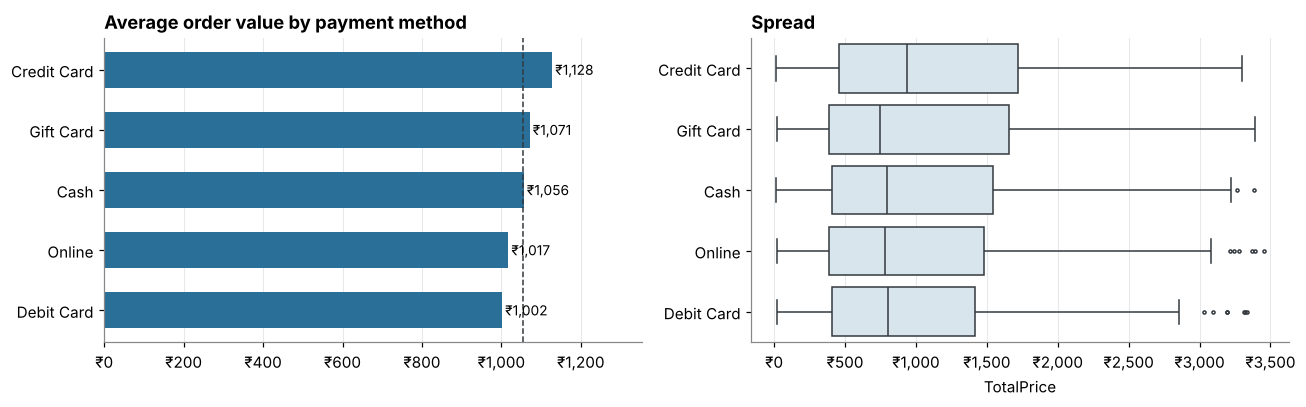

ANOVA p = 0.49


,Orders,Revenue,Avg_Order,Median_Order,Revenue_Share
PaymentMethod,,,,,
Credit Card,234,"263,847.63","1,127.55",938.09,0.21
Online,258,"262,442.94","1,017.22",780.92,0.21
Cash,246,"259,786.29","1,056.04",796.66,0.21
Gift Card,230,"246,323.92","1,070.97",745.05,0.19
Debit Card,232,"232,361.18","1,001.56",806.24,0.18


In [13]:
pay = summ('PaymentMethod')
fig, ax = plt.subplots(1,2, figsize=(12,3.8))
p = pay.sort_values('Avg_Order')
ax[0].barh(p.index, p.Avg_Order, color=ACC, height=.6); ax[0].xaxis.set_major_formatter(inr); ax[0].grid(axis='y',visible=False)
ax[0].axvline(df.TotalPrice.mean(), color=DARK, ls='--', lw=1); ax[0].set_title('Average order value by payment method')
for y,v in enumerate(p.Avg_Order): ax[0].text(v+8, y, f'₹{v:,.0f}', va='center', fontsize=9)
ax[0].set_xlim(0, p.Avg_Order.max()*1.2)
sns.boxplot(data=df, y='PaymentMethod', x='TotalPrice', order=p.index[::-1], color='#d6e6f0', linecolor=DARK, fliersize=2, ax=ax[1])
ax[1].xaxis.set_major_formatter(inr); ax[1].set_ylabel(''); ax[1].set_title('Spread'); ax[1].grid(axis='y',visible=False)
save('08_payment')
f,pv = stats.f_oneway(*[g.TotalPrice for _,g in df.groupby('PaymentMethod')]); print(f'ANOVA p = {pv:.2f}'); pay

**What it shows:** Credit Card has the highest average order (₹1,128) and Debit Card the lowest (₹1,002), a ₹126 gap (~12% of the lower figure). Online has the most orders (258) but only the second-lowest average. ANOVA p = 0.49 → **the gap is within normal sampling noise**; payment method does not meaningfully predict order value in this dataset.

### 8c. Order status vs revenue

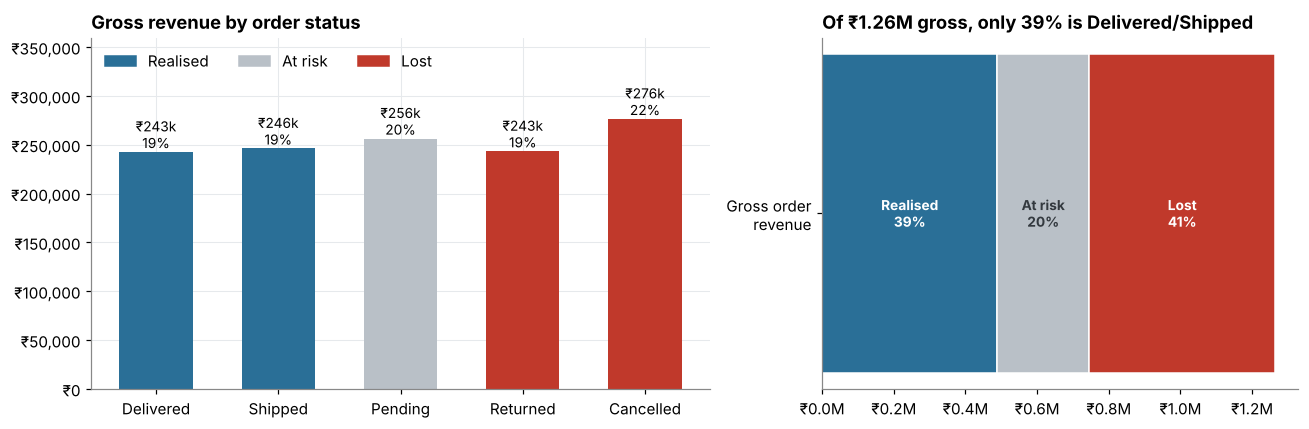

Lost (Cancelled+Returned): ₹519,674 = 41.1% of gross revenue
ANOVA (order value by status) p = 0.55
Product      Laptop  Tablet  Monitor  Chair  Desk  Phone  Printer
OrderStatus                                                      
Lost           0.43    0.43     0.43   0.41  0.40   0.40     0.40


,Orders,Revenue,Avg_Order,Median_Order,Revenue_Share
OrderStatus,,,,,
Delivered,231,"242,600.32","1,050.22",789.57,0.19
Shipped,235,"246,159.58","1,047.49",816.64,0.19
Pending,237,"256,328.15","1,081.55",869.80,0.20
Returned,247,"243,277.70",984.93,754.44,0.19
Cancelled,250,"276,396.21","1,105.58",875.48,0.22


In [14]:
st = summ('OrderStatus').reindex(['Delivered','Shipped','Pending','Returned','Cancelled'])
kind = {'Delivered':'Realised','Shipped':'Realised','Pending':'At risk','Returned':'Lost','Cancelled':'Lost'}
colr = {'Realised':ACC,'At risk':GREY,'Lost':RED}
fig, ax = plt.subplots(1,2, figsize=(12,4), gridspec_kw={'width_ratios':[1.3,1]})
ax[0].bar(st.index, st.Revenue, color=[colr[kind[i]] for i in st.index], width=.6)
for x,v in enumerate(st.Revenue): ax[0].text(x, v+4000, f'₹{v/1000:,.0f}k\n{v/st.Revenue.sum():.0%}', ha='center', fontsize=9)
ax[0].yaxis.set_major_formatter(inr); ax[0].set_title('Gross revenue by order status')
from matplotlib.patches import Patch
ax[0].legend(handles=[Patch(color=c,label=k) for k,c in colr.items()], frameon=False, loc='upper left', ncol=3)
ax[0].set_ylim(0, st.Revenue.max()*1.3)
grp = df.assign(Group=df.OrderStatus.map(kind)).groupby('Group').TotalPrice.sum().reindex(['Realised','At risk','Lost'])
ax[1].barh(['Gross order\nrevenue'], [grp.sum()], color='#e6e9ec')
left=0
for k,v in grp.items():
    ax[1].barh(['Gross order\nrevenue'], [v], left=left, color=colr[k], edgecolor='white'); ax[1].text(left+v/2, 0, f'{k}\n{v/grp.sum():.0%}', ha='center', va='center', color='white' if k!='At risk' else DARK, fontsize=9, fontweight='bold'); left+=v
ax[1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'₹{x/1e6:.1f}M')); ax[1].set_title(f'Of ₹{grp.sum()/1e6:.2f}M gross, only {grp.Realised/grp.sum():.0%} is Delivered/Shipped'); ax[1].grid(visible=False)
save('09_status')
print(f"Lost (Cancelled+Returned): ₹{grp['Lost']:,.0f} = {grp['Lost']/grp.sum():.1%} of gross revenue")
f,pv = stats.f_oneway(*[g.TotalPrice for _,g in df.groupby('OrderStatus')]); print(f'ANOVA (order value by status) p = {pv:.2f}')
print(pd.crosstab(df.Product, df.OrderStatus, normalize='index').round(2).assign(Lost=lambda x: x.Cancelled+x.Returned).sort_values('Lost', ascending=False)[['Lost']].T.to_string())
st

**What it shows — the most important result in the analysis.** Gross order revenue is ₹1.265M, but **₹519.7k (41%) sits in Cancelled or Returned orders**. Only **₹488.8k (39%) is Delivered or Shipped**; ₹256.3k (20%) is Pending.

Cancelled orders have the *highest* average value (₹1,106) while Returned have the lowest (₹985), but the difference is not significant (p = 0.55) — high-value orders are not disproportionately cancelled. The cancellation/return problem is **broad-based, not concentrated in one product** (Cancelled+Returned is 40%–43% of orders for every product), so it points at process (checkout, fulfilment, returns policy) rather than a bad SKU.

### 8d. Bonus — marketing levers (CouponCode, ReferralSource)

In [15]:
cp, rf = summ('CouponCode'), summ('ReferralSource')
print(cp[['Orders','Revenue','Avg_Order']].to_string(), '\n'); print(rf[['Orders','Revenue','Avg_Order']].to_string())
for c in ['CouponCode','ReferralSource']:
    f,pv = stats.f_oneway(*[g.TotalPrice for _,g in df.groupby(c)]); print(f'{c}: ANOVA p = {pv:.2f}')

            Orders    Revenue  Avg_Order
CouponCode                              
FREESHIP       313 335,036.99   1,070.41
No Coupon      309 322,401.41   1,043.37
SAVE10         286 304,840.02   1,065.87
WINTER15       292 302,483.54   1,035.90 

                Orders    Revenue  Avg_Order
ReferralSource                              
Instagram          259 275,285.45   1,062.88
Email              250 261,808.55   1,047.23
Google             241 250,441.48   1,039.18
Facebook           228 250,410.90   1,098.29
Referral           222 226,815.58   1,021.69
CouponCode: ANOVA p = 0.94
ReferralSource: ANOVA p = 0.89


Coupon users (₹1,036–₹1,070 avg) spend about the same as non-coupon users (₹1,043), so **coupons are not visibly lifting basket size**. (The dataset has no discount amount, so true coupon cost is unknown.) Instagram brings the most orders and revenue (259 orders, ₹275k); Referral the fewest (222, ₹227k). Average-order differences by channel are not significant.

## 9. Business insights — the "So What?" test

| # | What the data says | So what? (business diagnosis) | Suggested action |
|---|---|---|---|
| 1 | **41% of gross revenue (₹519.7k)** is in Cancelled/Returned orders; only 39% is Delivered/Shipped | Only 39% of gross revenue is realised (Delivered/Shipped); the leak is across *all* products | Audit checkout → fulfilment → returns flow; report **net** revenue; track cancellation reasons |
| 2 | TotalPrice is right-skewed (mean ₹1,054 vs median ₹824) | Averages mislead; half of orders are below ₹824 | Use **median** in reporting; set free-shipping/bundle thresholds near ₹1,000–1,500 to lift typical baskets |
| 3 | 8 IQR outliers (> ₹3,330): all Quantity 5 × price ≈₹670–690; **4 of 8 cancelled/returned** | Large orders are legitimate but fragile | Add a verification/confirmation step for orders above ~₹3,300 |
| 4 | Jan–Jun brings ~61% of revenue; June is the peak; **H1 revenue down ~10% in each of 2024 and 2025** | Demand is front-loaded and H1 is weakening | Plan stock/marketing around H1; run a H2 campaign; investigate the H1 decline |
| 5 | Product, payment, coupon and channel differences are **not statistically significant** | No single "winner" to double down on; Phone is lowest but may be noise | Don't reallocate budget on these gaps; run controlled tests first |
| 6 | UnitPrice↔Quantity r ≈ 0.02; UnitPrice↔TotalPrice 0.72 is arithmetic | Customers don't cut quantity when prices are higher | Test price/volume offers; don't present 0.72 as causal |

### Limitations & next steps
- **Gross vs net:** all revenue figures include Cancelled/Returned/Pending orders unless stated. A net-revenue view is the natural next analysis.
- **Synthetic-looking data:** flat distributions, products with identical ₹11–₹700 price ranges, and near-equal category splits suggest generated data. Treat findings as an exercise in method.
- **Short window:** 30 months; 2025 is half a year, so use like-for-like comparisons.
- **Correlation ≠ causation:** hidden variables (seasonality, promotions, customer segment) are not in the data.
- **Next:** Project 3 dashboard on net revenue, status funnel and H1/H2 seasonality.